1. First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

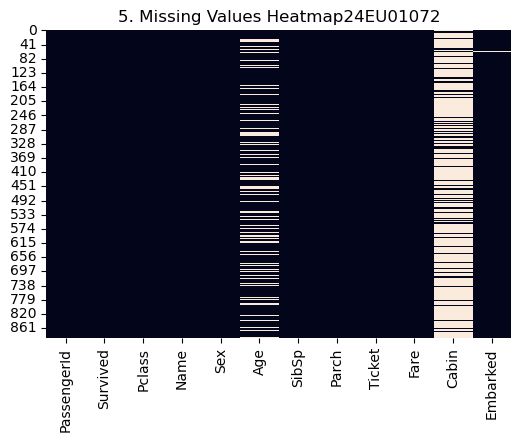

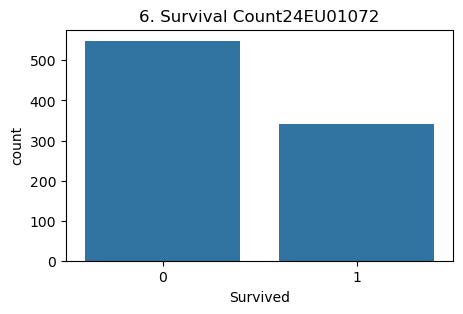

C:\Users\24eu01072\AppData\Local\Temp\ipykernel_1668\2543429384.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\24eu01072\AppData\Local\Temp\ipykernel_1668\2543429384.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy


7. After Preprocessing:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


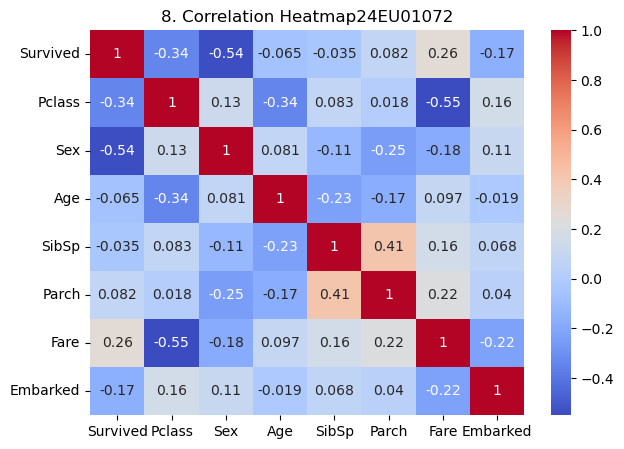


9. Train-Test Data:
X_train: (712, 7)
X_test : (179, 7)
y_train: (712,)
y_test : (179,)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# 1. Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("1. First 5 Rows:")
print(df.head())


# 2. Dataset Shape
print("\n2. Dataset Shape:")
print(df.shape)


# 3. Dataset Information
print("\n3. Dataset Info:")
print(df.info())


# 4. Missing Values
print("\n4. Missing Values:")
print(df.isnull().sum())


# 5. Missing Value Graph
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("5. Missing Values Heatmap24EU01072")
plt.show()


# 6. Survival Count Graph
plt.figure(figsize=(5,3))
sns.countplot(x="Survived", data=df)
plt.title("6. Survival Count24EU01072")
plt.show()


# Remove unnecessary columns
df.drop(['PassengerId','Name','Ticket','Cabin'],
        axis=1, inplace=True)


# Fill Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


# Encode Data
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])


# 7. Processed Dataset
print("\n7. After Preprocessing:")
print(df.head())


# 8. Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("8. Correlation Heatmap24EU01072")
plt.show()


# Split Dataset
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)




# 9. Train-Test Size
print("\n9. Train-Test Data:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

